## Project: The Bionic Bat – Fundamental SNN Mechanisms for Radar

Goal: To implement and visualize the core biological mechanisms found in bat echolocation (SNNs) and apply them to radar signal processing.

Scope: This notebook isolates four specific mechanisms identified in recent literature:

LIF Dynamics: How a neuron "leaks" and "integrates" radar pulses.

Encoding: Rate Coding vs. Latency Coding (The "Timing" hypothesis).

Synchrony: Detecting coincident features (The "AND" gate).

Navigation: Binaural error calculation for direction finding.

Dependencies: snntorch, torch, matplotlib, numpy

--------------------

## Papers:

1. Paper: Radar Emitter Recognition Based on Spiking Neural Networks
2. Paper: Bat echolocation processing using first-spike latency coding
3. Paper: Efficient and Robust Spiking Neural Circuit for Navigation...
4. Paper: Computing with Neural Synchrony

-----------------

### Cell 1: Setup & Imports

Standard imports. We will use snntorch for the neuron models and matplotlib for the "Raptor plots" (spike rasters).

In [3]:
import torch
import snntorch as snn
from snntorch import spikeplot as splt
import matplotlib.pyplot as plt
import numpy as np

# Function to make plots look professional
def plot_voltage_and_spikes(mem_rec, spk_rec, title="Neuron Activity"):
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Plot Membrane Potential (Voltage)
    ax[0].plot(mem_rec, color='teal', label="Membrane Potential")
    ax[0].axhline(y=1.0, color='r', linestyle='--', label="Threshold")
    ax[0].set_ylabel("Voltage ($V_{mem}$)")
    ax[0].set_title(f"{title} - Dynamics")
    ax[0].legend(loc='upper right')

    # Plot Spikes (Raster Plot)
    # splt.raster handles the "Rastor plot" visualization
    splt.raster(spk_rec, ax[1], c='black', marker='|')
    ax[1].set_ylabel("Neuron Index")
    ax[1].set_xlabel("Time Steps")
    ax[1].set_title("Spike Raster (Raptor Plot)")
    ax[1].set_yticks([]) # Hide y-ticks for single neuron

    plt.tight_layout()
    plt.show()

### Cell 2: The LIF Mechanism (Paper 1)

Context: "Radar Emitter Recognition Based on SNNs". Mechanism: The Leaky Integrate-and-Fire (LIF) neuron.

This block demonstrates the fundamental unit. We simulate a "Radar Pulse" (a sine wave). The neuron integrates this energy. If the energy rises faster than the "leak," the neuron fires.

Key Variable: beta (The decay rate). A high beta (e.g., 0.9) means a long memory (slow leak). A low beta (e.g., 0.5) means a short memory (fast leak).

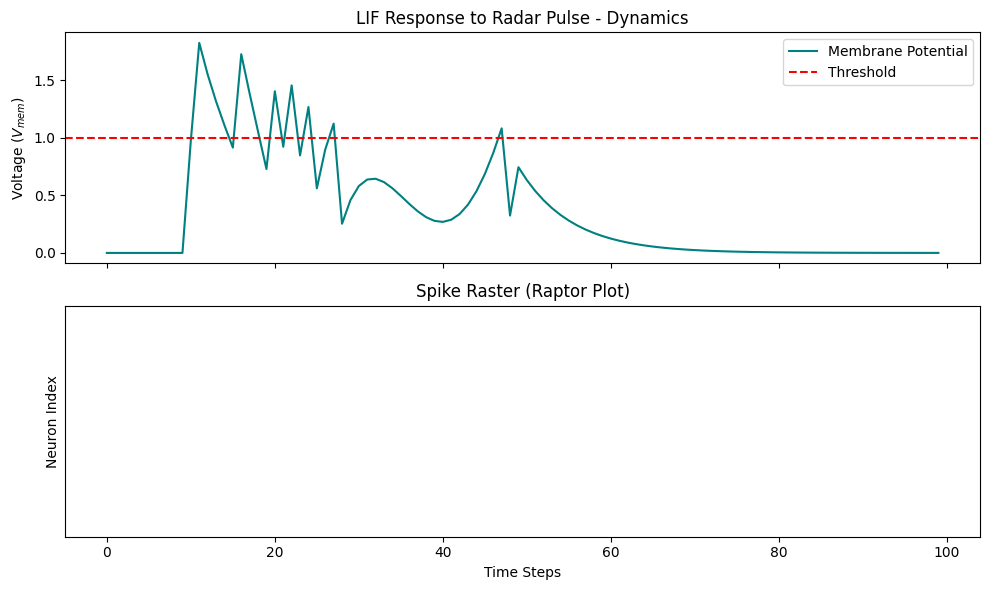

In [4]:
# 1. Setup the Simulation
time_steps = 100
beta = 0.85  # Decay rate (The "Leak")
threshold = 1.0
lif = snn.Leaky(beta=beta, threshold=threshold) # Initialize the neuron

# 2. Create a Synthetic Radar Pulse (Analog Input)
# A simple sine wave packet representing a radar return
t = np.linspace(0, 4*np.pi, time_steps)
radar_input = torch.tensor(np.sin(t) * 0.5 + 0.5).float() # Normalize 0 to 1
# Add a quiet period at the start and end
radar_input[:10] = 0
radar_input[50:] = 0

# 3. Run the SNN Simulation
mem = lif.init_leaky() # Reset membrane potential
mem_rec = []
spk_rec = []

for step in range(time_steps):
    # Get the input for this time step
    # We need to unsqueeze to add a "batch" dimension for snntorch
    cur_in = radar_input[step].unsqueeze(0)

    # Run the neuron
    spk, mem = lif(cur_in, mem)

    # Store data for plotting
    mem_rec.append(mem.item())
    spk_rec.append(spk.unsqueeze(0)) # Keep spike as tensor for plotting

# Stack spikes for the raptor plot
spk_rec = torch.stack(spk_rec)

# 4. Visualize
plot_voltage_and_spikes(mem_rec, spk_rec, title="LIF Response to Radar Pulse")

### Cell 3: Rate vs. Latency Encoding (Papers 1 & 2)

Context: "Radar Emitter Rec" (Rate) vs. "Bat Echolocation using First-Spike Latency" (Latency).

This is a critical comparison.

Rate Coding: Strong input → Many spikes. (Robust, but slow).

Latency Coding: Strong input → Early spike. (Fast, preserves timing info).

In [5]:
# Parameters
beta = 0.9
lif_rate = snn.Leaky(beta=beta, threshold=1.0)
lif_latency = snn.Leaky(beta=beta, threshold=1.0)

# Inputs: Weak Signal vs Strong Signal
# Create 50 timesteps
weak_input = torch.ones(50) * 0.2  # Constant low current
strong_input = torch.ones(50) * 1.5 # Constant high current

def run_neuron(neuron, input_data):
    mem = neuron.init_leaky()
    spk_rec = []
    for x in input_data:
        spk, mem = neuron(x.unsqueeze(0), mem)
        spk_rec.append(spk.item())
    return spk_rec

# Run Simulations
spikes_weak = run_neuron(lif_rate, weak_input)
spikes_strong = run_neuron(lif_rate, strong_input)

# Analyze
spike_count_weak = sum(spikes_weak)
spike_count_strong = sum(spikes_strong)

# Find First Spike Latency (FSL)
# np.argmax returns the index of the first '1' (True)
try:
    fsl_weak = spikes_weak.index(1)
except ValueError:
    fsl_weak = "Never Fired"

try:
    fsl_strong = spikes_strong.index(1)
except ValueError:
    fsl_strong = "Never Fired"

print(f"--- Comparison ---")
print(f"Weak Input:  Count={spike_count_weak} spikes | First Spike at t={fsl_weak}")
print(f"Strong Input: Count={spike_count_strong} spikes | First Spike at t={fsl_strong}")
print(f"\nObservation: The Strong signal has a HIGHER rate, but a LOWER latency.")

--- Comparison ---
Weak Input:  Count=6.0 spikes | First Spike at t=6
Strong Input: Count=50.0 spikes | First Spike at t=0

Observation: The Strong signal has a HIGHER rate, but a LOWER latency.


### Cell 4: Coincidence Detection (Paper 4)

Context: "Computing with Neural Synchrony". Mechanism: The "AND" Gate.

How does a bat know a specific feature is present? It requires two neurons to fire at the same time. We simulate this by lowering beta (increasing the leak). If beta is low, the neuron forgets input A before input B arrives, unless they arrive simultaneously.

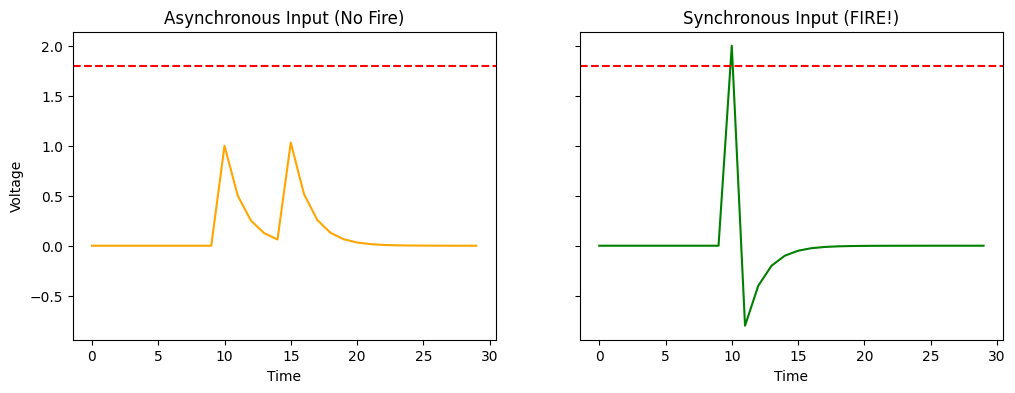

In [6]:
# 1. Create a "Coincidence Detector" Neuron
# A low beta (0.5) means it forgets 50% of its voltage every step!
# It requires simultaneous input to cross the threshold.
coincidence_neuron = snn.Leaky(beta=0.5, threshold=1.8)

# 2. Create Inputs
# Case A: Asynchronous (Input 1 at t=10, Input 2 at t=15)
input_A_async = torch.zeros(30)
input_A_async[10] = 1.0
input_A_async[15] = 1.0 # Arrives too late!

# Case B: Synchronous (Both at t=10)
input_B_sync = torch.zeros(30)
input_B_sync[10] = 2.0 # Both inputs summing up at the same moment

# 3. Run Simulation
def test_synchrony(input_tensor, label):
    mem = coincidence_neuron.init_leaky()
    mem_trace = []
    spk_trace = []
    for x in input_tensor:
        spk, mem = coincidence_neuron(x.unsqueeze(0), mem)
        mem_trace.append(mem.item())
        spk_trace.append(spk.item())
    return mem_trace, spk_trace

mem_async, spk_async = test_synchrony(input_A_async, "Async")
mem_sync, spk_sync = test_synchrony(input_B_sync, "Sync")

# 4. Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax[0].plot(mem_async, color='orange')
ax[0].axhline(1.8, linestyle='--', color='r')
ax[0].set_title("Asynchronous Input (No Fire)")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Voltage")

ax[1].plot(mem_sync, color='green')
ax[1].axhline(1.8, linestyle='--', color='r')
ax[1].set_title("Synchronous Input (FIRE!)")
ax[1].set_xlabel("Time")

plt.show()

### Cell 5: Navigation (Binaural Difference) (Paper 3)

Context: "Robust Spiking Neural Circuit for Navigation". Mechanism: Azimuth Detection via Interaural Level Difference (ILD).

We simulate the bat's ears. If the target is to the right, the Right Ear gets a stronger signal. The SNN computes the difference to steer the bat.

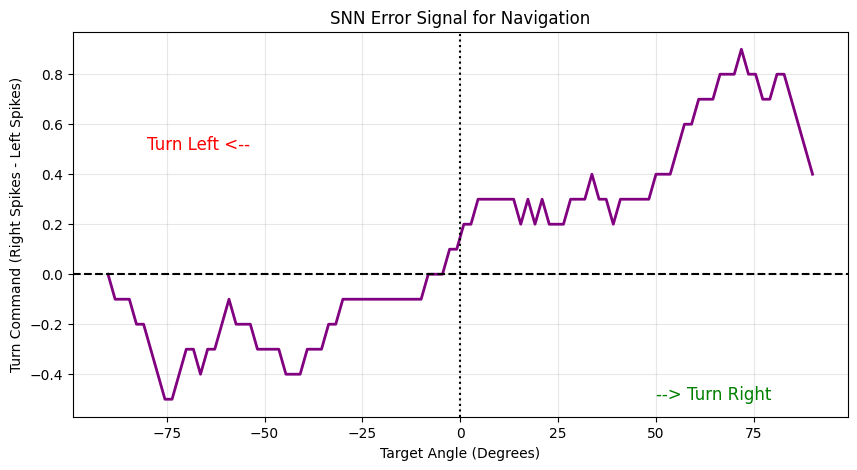

In [7]:
# 1. The Sensor Model (Cardioid Ears)
def ear_response(angle_deg, ear_offset_deg):
    # Simple attenuation based on angle
    angle_rad = np.deg2rad(angle_deg - ear_offset_deg)
    return 0.5 * (1 + np.cos(angle_rad))

# 2. Sweep a target across the field of view
target_angles = np.linspace(-90, 90, 100)
left_ear_vals = []
right_ear_vals = []

for angle in target_angles:
    # Left ear is at -30 deg, Right ear is at +30 deg
    left_ear_vals.append(ear_response(angle, -30))
    right_ear_vals.append(ear_response(angle, 30))

# 3. Generate Spikes (Rate Coding)
# We treat the ear value as a probability of spiking
left_spikes = [np.random.rand() < val for val in left_ear_vals]
right_spikes = [np.random.rand() < val for val in right_ear_vals]

# 4. Calculate SNN Error Signal (Right - Left)
# Smooth the spikes slightly to see the trend
window = 10
error_signal = np.convolve(np.array(right_spikes, dtype=int) - np.array(left_spikes, dtype=int),
                           np.ones(window)/window, mode='same')

# 5. Plot
plt.figure(figsize=(10, 5))
plt.plot(target_angles, error_signal, color='purple', linewidth=2)
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle=':')
plt.title("SNN Error Signal for Navigation")
plt.xlabel("Target Angle (Degrees)")
plt.ylabel("Turn Command (Right Spikes - Left Spikes)")
plt.text(-80, 0.5, "Turn Left <--", fontsize=12, color='red')
plt.text(50, -0.5, "--> Turn Right", fontsize=12, color='green')
plt.grid(True, alpha=0.3)
plt.show()